In [1]:
%load_ext autoreload
%autoreload 2
import torch
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
from constraints.generators import ArteryGeneratorAffine, AffineSampleBound,ROT_ONLY
from constraints.visu.helpers import show_torch_image

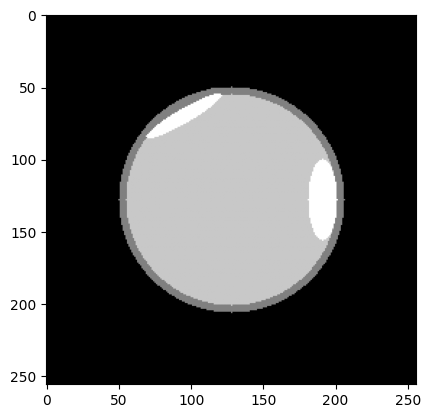

In [ ]:
def create_one_hot_masks(height, width, ellipses_list):
    """
    ellipses_list: list of dicts with 'center' (h,k), 'axes' (a,b), 'class_id'
    """
    num_classes = max(e['class_id'] for e in ellipses_list) + 1
    masks = np.zeros((num_classes, height, width), dtype=np.uint8)
    
    # Create coordinate grids
    y, x = np.ogrid[:height, :width]
    
    for e in ellipses_list:
        h, k = e['center']
        a, b = e['axes']
        cls = e['class_id']
        angle = e.get('angle', 0)  # Default angle is 0 if not provided
        
        transform_x = (x - h) * np.cos(angle) + (y - k) * np.sin(angle)
        transform_y = -(x - h) * np.sin(angle) + (y - k) * np.cos(angle)
        # Ellipse inequality calculation
        ellipse_mask = (transform_x**2 / a**2 + transform_y**2 / b**2) <= 1
        
        # Add to the specific class channel
        masks[cls] = np.logical_or(masks[cls], ellipse_mask)
        # Ensure the mask is binary (0 or 1)
        masks[cls] = masks[cls].astype(np.uint8)
        # zero out the overlapping areas in other classes
        for other_cls in range(num_classes):
            if other_cls != cls:
                masks[other_cls] = np.logical_and(masks[other_cls], ~ellipse_mask).astype(np.uint8)
            
        
    return np.transpose(masks, (1, 2, 0))*255


mask = create_one_hot_masks(256, 256, [
    {'center': (128, 128), 'axes': (78, 78), 'class_id': 0},  # Red ellipse
    {'center': (128, 128), 'axes': (73, 73), 'class_id': 1},  # Green ellipse
    {'center': (95, 65), 'axes': (5, 28), 'class_id': 0, "angle": np.pi/3},    # RED TO CONNECT
    {'center': (95, 70), 'axes': (5, 30), 'class_id': 2, "angle": np.pi/3},    # Blue ellipse
    {'center': (191, 128), 'axes': (10, 28), 'class_id': 2},    # Blue ellipse
])


 
plt.imshow(mask)  # Transpose to (H, W, C) for visualization
# save the masks as a PNG image
Image.fromarray(mask).save("mask.png")
# create an input image as grayscale version of the original image
divider = np.array([128/255, 200/255, 255/255])

img = np.sum(mask * divider[None, None, :], axis=2).astype(np.uint8)

plt.imshow(img, cmap='gray')



Image.fromarray(img, mode='L').save("input.png")


(256, 256, 3)


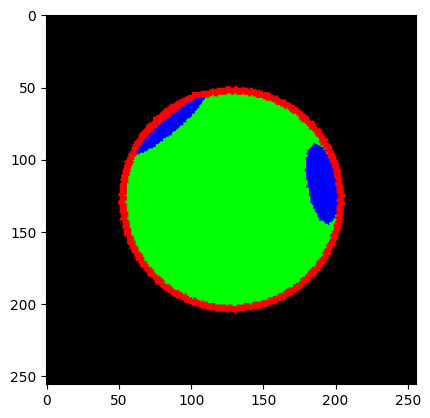

In [59]:
# Make template as rotated mask
def deg2rad(degrees):
    return degrees * (np.pi / 180)


ANGLE = deg2rad(10)  # 45 degrees in radians
template = mask.copy()
template = Image.fromarray(template).rotate(np.degrees(ANGLE))
plt.imshow(template)
print(mask.shape)


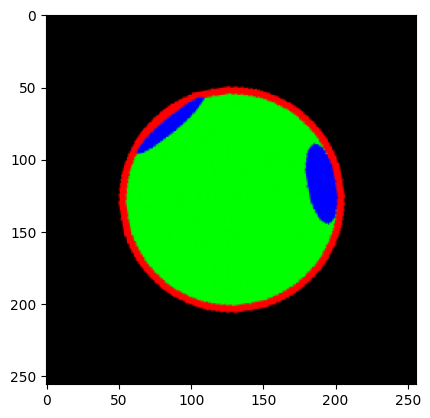

In [60]:
# or via torch (so can test if the differentiable rotation works as expected)
import torch.nn.functional as F
rot_mtx = torch.tensor([[np.cos(ANGLE), -np.sin(ANGLE), 0],
                        [np.sin(ANGLE),  np.cos(ANGLE), 0],
                        ], dtype=torch.float32)
H,W = mask.shape[:2]

grid = F.affine_grid(rot_mtx.unsqueeze(0),size=(1,1,H,W),align_corners=False)

transformed_mask = F.grid_sample(torch.tensor(mask).permute(2,0,1).unsqueeze(0).float(), grid, align_corners=False)
transformed_mask = transformed_mask.squeeze(0).permute(1,2,0).numpy().astype(np.uint8)

plt.imshow(transformed_mask)
plt.show()
Image.fromarray(transformed_mask).save("template.png")



# Generator

torch.Size([1, 256, 256]) torch.Size([3, 256, 256]) torch.Size([3, 256, 256]) tensor([[-0.9623, -0.2718,  0.0000],
        [ 0.2718, -0.9623,  0.0000]])


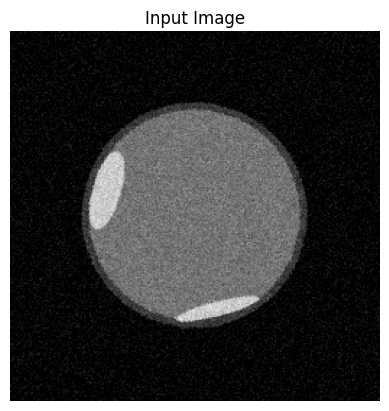

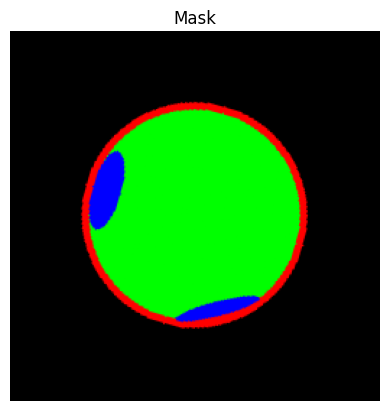

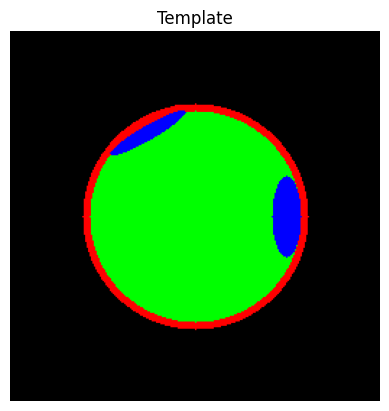

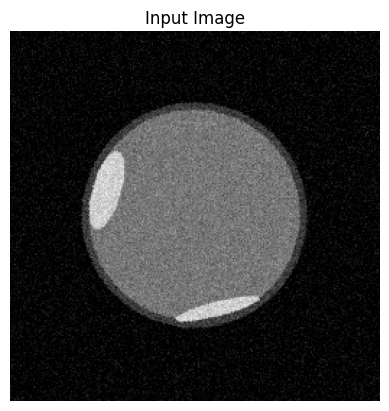

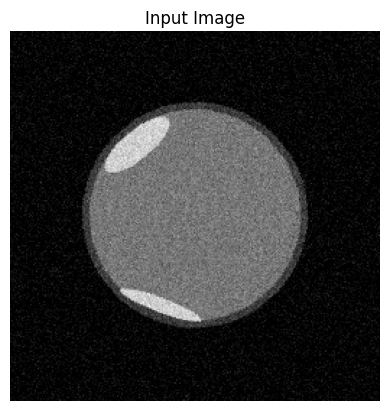

In [38]:
dataset= ArteryGeneratorAffine(
    fixed_seed=42,
    num_samples=1000,
    img_size=(256, 256),
    sample_specs=ROT_ONLY,
    speckle=0.5
    )
    
sample = dataset[0]
img,mask,template,M = sample["img"],sample["mask"],sample["template"],sample["affine"]
print(img.shape, mask.shape, template.shape, M)
show_torch_image(img, title="Input Image",cmap="gray")
show_torch_image(mask, title="Mask")
show_torch_image(template, title="Template")

# assert consistency - if I quer
sample = dataset[0]
img2,mask2,template2,M2 = sample["img"],sample["mask"],sample["template"],sample["affine"]
show_torch_image(img2, title="Input Image",cmap="gray")
assert torch.allclose(mask, mask2)
sample = dataset[1]
img3,mask3,template3,M3 = sample["img"],sample["mask"],sample["template"],sample["affine"]
show_torch_image(img3, title="Input Image",cmap="gray")


In [37]:
ds[0]

(tensor([[[0.0481, 0.0453, 0.0000,  ..., 0.0818, 0.0501, 0.0396],
          [0.0000, 0.0115, 0.0114,  ..., 0.0226, 0.0149, 0.0660],
          [0.0679, 0.0298, 0.0131,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0303, 0.0000, 0.0000,  ..., 0.0317, 0.0000, 0.0172],
          [0.0850, 0.0259, 0.0000,  ..., 0.0143, 0.0455, 0.0324],
          [0.0000, 0.0000, 0.0140,  ..., 0.0000, 0.0000, 0.0000]]]),
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
    